In [68]:

from fastai.imports import *
np.set_printoptions(linewidth=130)

In [69]:
import os
from pathlib import Path
import pandas as pd
path = Path('../../training_excel_model/titanic')

df = pd.read_csv(path/'train.csv')
tst_df = pd.read_csv(path/'test.csv')
modes = df.mode().iloc[0]

In [70]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [71]:
def proc_data(df):
    df.Fare = df.Fare.fillna(0) 
    df.fillna(modes, inplace=True)
    df['LogFare'] = np.log1p(df.Fare)
    df.Embarked= pd.Categorical(df.Embarked)
    df.Sex= pd.Categorical(df.Sex)

proc_data(df)

In [72]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LogFare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S,2.202765
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,B96 B98,S,2.639057
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,3.433987
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,B96 B98,S,3.196630
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,3.433987


In [73]:
proc_data(tst_df)

In [74]:
cats=["Sex","Embarked"]
conts=['Age', 'SibSp', 'Parch', 'LogFare',"Pclass"]
dep="Survived"

In [75]:
df.Sex.head()


0      male
1    female
2    female
3    female
4      male
Name: Sex, dtype: category
Categories (2, object): ['female', 'male']

In [76]:
df.Sex.cat.codes.head()

0    1
1    0
2    0
3    0
4    1
dtype: int8

In [77]:
df.Embarked.cat.codes.head(10)

0    2
1    0
2    2
3    2
4    2
5    1
6    2
7    2
8    2
9    0
dtype: int8

In [78]:
#Binary splits

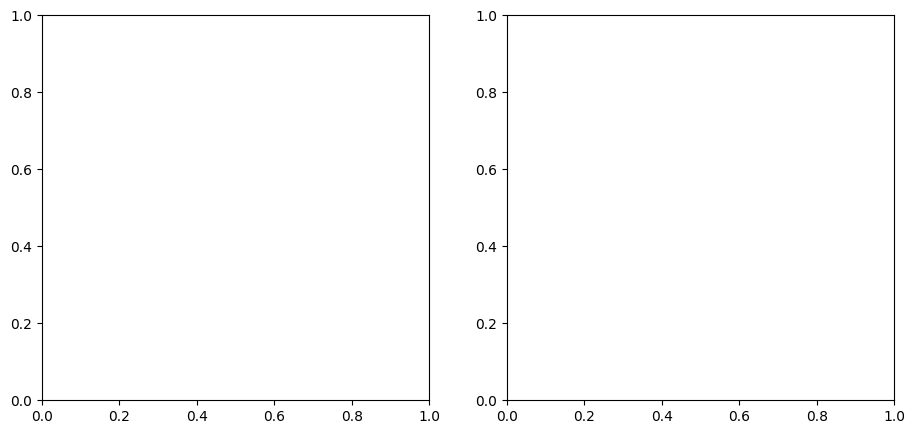

In [79]:
import seaborn as sns
fig,axs = plt.subplots(1,2, figsize=(11,5))


In [80]:
sns.barplot(data=df, y=dep, x="Sex", ax=axs[0]).set(title="Survival rate")

[Text(0.5, 1.0, 'Survival rate')]

In [81]:
sns.countplot(data=df, x="Sex", ax=axs[1]).set(title="Histogram");

In [82]:
from numpy import random
from sklearn.model_selection import train_test_split


In [83]:
random.seed(42)
trn_df,val_df = train_test_split(df, test_size=0.25)

In [84]:
trn_df[cats] = trn_df[cats].apply(lambda x: x.cat.codes)

In [85]:
val_df[cats] = val_df[cats].apply(lambda x: x.cat.codes)


In [86]:
def xs_y(df):
    xs = df[cats+conts].copy()
    return xs,df[dep] if dep in df else None

In [87]:
trn_xs,trn_y = xs_y(trn_df)
trn_xs
trn_y

298    1
884    0
247    1
478    0
305    1
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 668, dtype: int64

In [88]:
val_xs,val_y = xs_y(val_df)
val_xs


,Sex,Embarked,Age,SibSp,Parch,LogFare,Pclass
709,1,0,24.0,1,1,2.787834,3
439,1,2,31.0,0,0,2.442347,2
840,1,2,20.0,0,0,2.188856,3
720,0,2,6.0,0,1,3.526361,2
39,0,0,14.0,1,0,2.504848,3
...,...,...,...,...,...,...,...
880,0,2,25.0,0,1,3.295837,2
425,1,2,24.0,0,0,2.110213,3
101,1,2,24.0,0,0,2.185579,3
199,0,2,24.0,0,0,2.639057,2


In [89]:
pred = val_xs.Sex==0
pred


709    False
439    False
840    False
720     True
39      True
       ...  
880     True
425    False
101    False
199     True
424    False
Name: Sex, Length: 223, dtype: bool

In [90]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(val_y,pred)

0.21524663677130046

In [91]:
df_fare = trn_df[trn_df.LogFare>0]
df_fare

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LogFare
298,299,1,1,"Saalfeld, Mr. Adolphe",1,24.00,0,0,19988,30.5000,C106,2,3.449988
884,885,0,3,"Sutehall, Mr. Henry Jr",1,25.00,0,0,SOTON/OQ 392076,7.0500,B96 B98,2,2.085672
247,248,1,2,"Hamalainen, Mrs. William (Anna)",0,24.00,0,2,250649,14.5000,B96 B98,2,2.740840
478,479,0,3,"Karlsson, Mr. Nils August",1,22.00,0,0,350060,7.5208,B96 B98,2,2.142510
305,306,1,1,"Allison, Master. Hudson Trevor",1,0.92,1,2,113781,151.5500,C22 C26,2,5.027492
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,1,3,"Salkjelsvik, Miss. Anna Kristine",0,21.00,0,0,343120,7.6500,B96 B98,2,2.157559
270,271,0,1,"Cairns, Mr. Alexander",1,24.00,0,0,113798,31.0000,B96 B98,2,3.465736
860,861,0,3,"Hansen, Mr. Claus Peter",1,41.00,2,0,350026,14.1083,B96 B98,2,2.715244
435,436,1,1,"Carter, Miss. Lucile Polk",0,14.00,1,2,113760,120.0000,B96 B98,2,4.795791


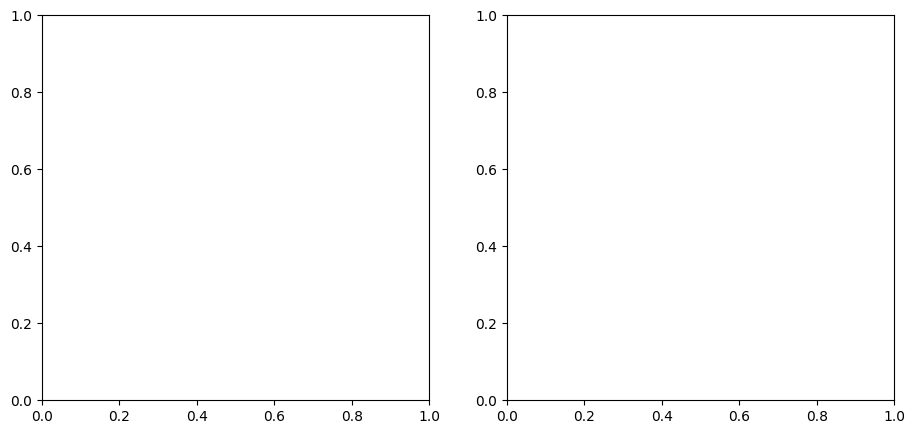

In [92]:
fig,axs = plt.subplots(1,2, figsize=(11,5))


In [93]:
sns.boxenplot(data=df_fare, x=dep, y="LogFare", ax=axs[0])


<Axes: xlabel='Survived', ylabel='LogFare'>

In [94]:
sns.kdeplot(data=df_fare, x="LogFare", ax=axs[1]);


In [95]:
preds = val_xs.LogFare>2.7


In [96]:
mean_absolute_error(val_y, preds)


0.336322869955157

In [97]:
def _side_score(side, y):
    tot = side.sum()
    if tot<=1: return 0
    return y[side].std()*tot

In [98]:

    
def score(col, y, split):
    lhs = col<=split
    return (_side_score(lhs,y) + _side_score(~lhs,y))/len(y)

In [99]:
score(trn_xs["Sex"], trn_y, 0.5)


np.float64(0.40787530982063946)

In [100]:
score(trn_xs["LogFare"], trn_y, 2.7)


np.float64(0.47180873952099694)

In [101]:

def iscore(nm, split):
    col = trn_xs[nm]
    return score(col, trn_y, split)

In [102]:
from ipywidgets import interact
interact(nm=conts, split=15.5)(iscore);
     

interactive(children=(Dropdown(description='nm', options=('Age', 'SibSp', 'Parch', 'LogFare', 'Pclass'), value…

In [103]:
interact(nm=cats, split=2)(iscore);


interactive(children=(Dropdown(description='nm', options=('Sex', 'Embarked'), value='Sex'), IntSlider(value=2,…

In [104]:
nm = "Age"
col = trn_xs[nm]
col

298    24.00
884    25.00
247    24.00
478    22.00
305     0.92
       ...  
106    21.00
270    24.00
860    41.00
435    14.00
102    21.00
Name: Age, Length: 668, dtype: float64

In [105]:
unq = col.unique()
unq

array([24.  , 25.  , 22.  ,  0.92, 26.  , 34.  , 21.  , 62.  , 18.  , 42.  , 57.  , 19.  , 20.  , 34.5 , 28.  , 23.  , 52.  ,
       30.  , 36.5 , 50.  , 27.  , 51.  , 36.  , 29.  , 40.  , 65.  , 17.  ,  4.  ,  1.  , 43.  , 38.  , 31.  , 39.  , 49.  ,
        3.  , 40.5 , 54.  , 16.  , 47.  , 60.  , 44.  , 45.  ,  8.  , 32.  , 15.  , 41.  , 33.  ,  9.  , 37.  , 46.  , 56.  ,
       59.  , 58.  , 28.5 ,  0.75, 35.  , 55.  ,  2.  , 14.  , 45.5 , 12.  , 11.  ,  7.  , 70.5 , 70.  , 48.  , 80.  , 55.5 ,
       14.5 , 10.  , 53.  , 32.5 , 74.  , 64.  ,  6.  ,  5.  , 24.5 ,  0.42, 61.  ,  0.67, 13.  ,  0.83])

In [106]:
unq.sort()
unq

array([ 0.42,  0.67,  0.75,  0.83,  0.92,  1.  ,  2.  ,  3.  ,  4.  ,  5.  ,  6.  ,  7.  ,  8.  ,  9.  , 10.  , 11.  , 12.  ,
       13.  , 14.  , 14.5 , 15.  , 16.  , 17.  , 18.  , 19.  , 20.  , 21.  , 22.  , 23.  , 24.  , 24.5 , 25.  , 26.  , 27.  ,
       28.  , 28.5 , 29.  , 30.  , 31.  , 32.  , 32.5 , 33.  , 34.  , 34.5 , 35.  , 36.  , 36.5 , 37.  , 38.  , 39.  , 40.  ,
       40.5 , 41.  , 42.  , 43.  , 44.  , 45.  , 45.5 , 46.  , 47.  , 48.  , 49.  , 50.  , 51.  , 52.  , 53.  , 54.  , 55.  ,
       55.5 , 56.  , 57.  , 58.  , 59.  , 60.  , 61.  , 62.  , 64.  , 65.  , 70.  , 70.5 , 74.  , 80.  ])

In [107]:
scores = np.array([score(col, trn_y, o) for o in unq if not np.isnan(o)])
score
unq[scores.argmin()]


np.float64(6.0)

In [108]:
def min_col(df, nm):
    col,y = df[nm],df[dep]
    unq = col.dropna().unique()
    scores = np.array([score(col, y, o) for o in unq if not np.isnan(o)])
    idx = scores.argmin()
    return unq[idx],scores[idx]

min_col(trn_df, "Age")

(np.float64(6.0), np.float64(0.478316717508991))

In [109]:
cols = cats+conts
{o:min_col(trn_df, o) for o in cols}

{'Sex': (np.int8(0), np.float64(0.40787530982063946)),
 'Embarked': (np.int8(0), np.float64(0.47883342573147836)),
 'Age': (np.float64(6.0), np.float64(0.478316717508991)),
 'SibSp': (np.int64(4), np.float64(0.4783740258817434)),
 'Parch': (np.int64(0), np.float64(0.4805296527841601)),
 'LogFare': (np.float64(2.4390808375825834), np.float64(0.4620823937736597)),
 'Pclass': (np.int64(2), np.float64(0.46048261885806596))}

In [110]:
cols.remove("Sex")
ismale = trn_df.Sex==1
males,females = trn_df[ismale],trn_df[~ismale]

In [111]:
{o:min_col(males, o) for o in cols}

{'Embarked': (np.int8(0), np.float64(0.3875581870410906)),
 'Age': (np.float64(6.0), np.float64(0.3739828371010595)),
 'SibSp': (np.int64(4), np.float64(0.3875864227586273)),
 'Parch': (np.int64(0), np.float64(0.3874704821461959)),
 'LogFare': (np.float64(2.803360380906535), np.float64(0.3804856231758151)),
 'Pclass': (np.int64(1), np.float64(0.38155442004360934))}

In [112]:
{o:min_col(females, o) for o in cols}


{'Embarked': (np.int8(0), np.float64(0.4295252982857327)),
 'Age': (np.float64(50.0), np.float64(0.4225927658431649)),
 'SibSp': (np.int64(4), np.float64(0.42319212059713535)),
 'Parch': (np.int64(3), np.float64(0.4193314500446158)),
 'LogFare': (np.float64(4.256321678298823), np.float64(0.41350598332911376)),
 'Pclass': (np.int64(2), np.float64(0.3335388911567601))}

In [113]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz

m = DecisionTreeClassifier(max_leaf_nodes=4).fit(trn_xs, trn_y);
     
m

DecisionTreeClassifier(max_leaf_nodes=4)

In [114]:
import graphviz

def draw_tree(t, df, size=10, ratio=0.6, precision=2, **kwargs):
    s=export_graphviz(t, out_file=None, feature_names=df.columns, filled=True, rounded=True,
                      special_characters=True, rotate=False, precision=precision, **kwargs)
    return graphviz.Source(re.sub('Tree {', f'Tree {{ size={size}; ratio={ratio}', s))

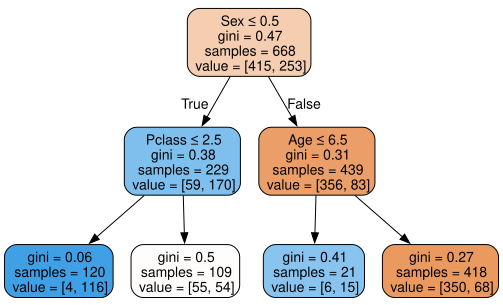

In [115]:
draw_tree(m, trn_xs, size=10)

In [116]:
def gini(cond):
    act = df.loc[cond, dep]
    return 1 - act.mean()**2 - (1-act).mean()**2

In [117]:
gini(df.Sex=='female'), gini(df.Sex=='male')


(np.float64(0.3828350034484158), np.float64(0.3064437162277842))

In [118]:
mean_absolute_error(val_y, m.predict(val_xs))


0.2242152466367713

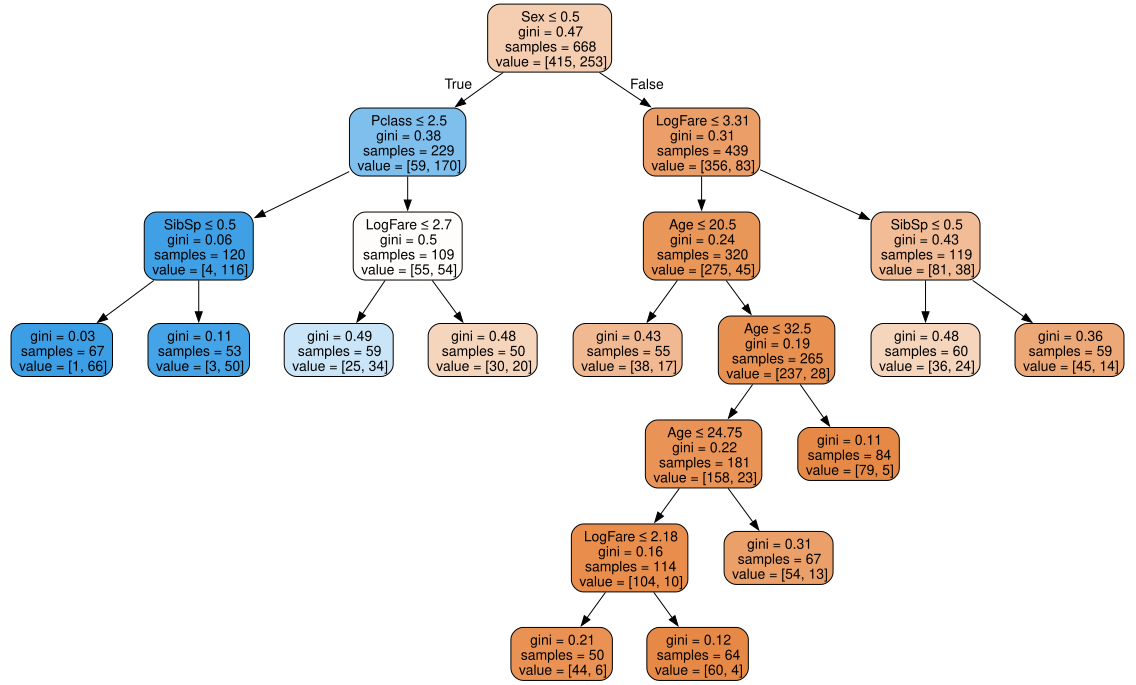

In [119]:
m = DecisionTreeClassifier(min_samples_leaf=50)
m.fit(trn_xs, trn_y)
draw_tree(m, trn_xs, size=25)
     

In [120]:
mean_absolute_error(val_y, m.predict(val_xs))


0.18385650224215247

In [121]:
tst_df[cats] = tst_df[cats].apply(lambda x: x.cat.codes)
tst_xs,_ = xs_y(tst_df)



In [122]:
def subm(preds, suff):
    tst_df['Survived'] = preds
    sub_df = tst_df[['PassengerId','Survived']]
    sub_df.to_csv(f'sub-{suff}.csv', index=False)

subm(m.predict(tst_xs), 'tree')

In [123]:
df.Embarked.head()


0    S
1    C
2    S
3    S
4    S
Name: Embarked, dtype: category
Categories (3, object): ['C', 'Q', 'S']

In [124]:
df.Embarked.cat.codes.head()


0    2
1    0
2    2
3    2
4    2
dtype: int8

In [125]:
#The random forest

In [126]:
def get_tree(prop=0.75):
    n = len(trn_y)
    idxs = random.choice(n, int(n*prop))
    return DecisionTreeClassifier(min_samples_leaf=5).fit(trn_xs.iloc[idxs], trn_y.iloc[idxs])

In [127]:
trees = [get_tree() for t in range(100)]
trees

[DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionTreeClassifier(min_samples_leaf=5),
 DecisionT

In [128]:
all_probs = [t.predict(val_xs) for t in trees]
all_probs


[array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
        1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
        0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
        1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0]),
 array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
        1, 0, 1, 1,

In [129]:
avg_probs = np.stack(all_probs).mean(0)
avg_probs


array([0.17, 0.1 , 0.18, 0.99, 0.44, 0.97, 0.78, 0.09, 0.76, 1.  , 0.5 , 0.03, 0.06, 0.16, 0.04, 1.  , 0.37, 0.67, 0.05, 0.07,
       0.  , 0.63, 0.38, 0.02, 0.01, 0.15, 0.32, 0.11, 0.48, 0.48, 0.  , 0.63, 0.5 , 0.83, 0.04, 0.22, 0.16, 0.78, 0.99, 0.  ,
       0.03, 0.22, 0.  , 0.02, 0.38, 0.06, 0.06, 0.01, 0.05, 0.34, 0.94, 0.97, 0.11, 0.28, 0.05, 1.  , 0.2 , 0.97, 0.99, 0.58,
       0.11, 0.99, 0.99, 0.12, 0.02, 0.99, 0.07, 0.11, 0.18, 0.97, 0.96, 0.98, 0.59, 1.  , 0.01, 0.  , 0.74, 1.  , 1.  , 0.65,
       0.02, 1.  , 1.  , 0.  , 0.42, 0.26, 1.  , 1.  , 0.2 , 0.02, 0.31, 0.03, 0.1 , 0.  , 0.  , 0.16, 0.18, 0.02, 1.  , 0.11,
       0.09, 0.02, 1.  , 0.01, 0.07, 0.26, 1.  , 0.05, 0.03, 0.38, 0.99, 0.02, 0.99, 0.6 , 0.2 , 0.01, 0.26, 0.08, 1.  , 0.03,
       0.05, 1.  , 0.99, 0.92, 0.08, 0.52, 0.99, 0.4 , 0.29, 0.01, 0.69, 0.17, 0.01, 0.64, 0.63, 0.32, 1.  , 0.24, 0.01, 0.54,
       0.02, 0.99, 0.01, 0.05, 0.23, 1.  , 0.02, 0.06, 0.98, 0.02, 0.13, 0.02, 0.12, 0.3 , 0.  , 0.05, 0.26, 0.

In [130]:
mean_absolute_error(val_y, avg_probs)

0.22748878923766816

In [131]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(100, min_samples_leaf=5)
rf

RandomForestClassifier(min_samples_leaf=5)

In [132]:
rf.fit(trn_xs, trn_y);
mean_absolute_error(val_y, rf.predict(val_xs))

0.18834080717488788

In [133]:
subm(rf.predict(tst_xs), 'rf')


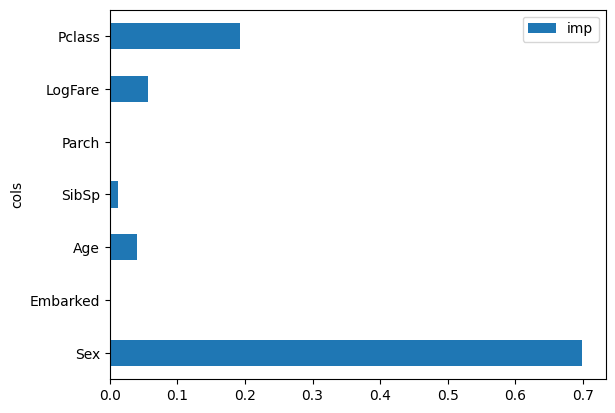

In [134]:
pd.DataFrame(dict(cols=trn_xs.columns, imp=m.feature_importances_)).plot('cols', 'imp', 'barh');
